In [56]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Reading in fastp output

In [57]:
AD_fastp_summary = pd.read_csv("../../../data/ChopTF/TREBL_ChopTF_AD_fastp/logs/fastp_summary.csv").dropna()
AD_fastp_summary["rep"] = AD_fastp_summary["sample"].str.extract("AD_(\d+)_").astype(int)
AD_fastp_summary["time"] = AD_fastp_summary["sample"].str.extract("AD_\d+_(\d+)").astype(int)
AD_fastp_summary["type"] = "AD"
AD_fastp_summary

,sample,reads_passed,reads_filtered,total_reads,filtered_percent,rep,time,type
0,AD_4_60_S30_R1_001,15156141,27125,15183266,0.178651,4,60,AD
1,AD_4_50_S29_R1_001,14604343,22258,14626601,0.152175,4,50,AD
2,AD_2_60_S10_R1_001,14569396,22305,14591701,0.152861,2,60,AD
3,AD_3_20_S16_R1_001,14471172,48866,14520038,0.336542,3,20,AD
4,AD_2_10_S4_R1_001,14163000,19638,14182638,0.138465,2,10,AD
5,AD_3_40_S18_R1_001,14126017,17960,14143977,0.126980,3,40,AD
6,AD_2_30_S7_R1_001,13932000,22683,13954683,0.162548,2,30,AD
7,AD_4_2_S22_R1_001,13879668,17285,13896953,0.124380,4,2,AD
8,AD_3_50_S19_R1_001,13677017,18354,13695371,0.134016,3,50,AD
9,AD_3_10_S14_R1_001,13655710,17547,13673257,0.128331,3,10,AD


In [58]:
RT_fastp_summary = pd.read_csv("../../../data/ChopTF/TREBL_ChopTF_RP_fastp/logs/fastp_summary.csv").dropna()
RT_fastp_summary["rep"] = RT_fastp_summary["sample"].str.extract("RP_(\d+)_").astype(int)
RT_fastp_summary["time"] = RT_fastp_summary["sample"].str.extract("RP_\d+_(\d+)").astype(int)
RT_fastp_summary["type"] = "RT"
RT_fastp_summary

,sample,reads_passed,reads_filtered,total_reads,filtered_percent,rep,time,type
0,RP_2_60_S40_R1_001,57904291,70491,57974782,0.121589,2,60,RT
1,RP_3_60_S50_R1_001,53524447,70395,53594842,0.131347,3,60,RT
2,RP_4_60_S60_R1_001,50191298,59520,50250818,0.118446,4,60,RT
3,RP_2_50_S39_R1_001,50196188,51712,50247900,0.102914,2,50,RT
4,RP_3_50_S49_R1_001,48209610,59535,48269145,0.123340,3,50,RT
5,RP_4_40_S58_R1_001,45028935,53981,45082916,0.119737,4,40,RT
6,RP_3_40_S48_R1_001,39320505,49854,39370359,0.126628,3,40,RT
7,RP_2_40_S38_R1_001,37719653,41352,37761005,0.109510,2,40,RT
8,RP_4_50_S59_R1_001,35075095,47842,35122937,0.136213,4,50,RT
9,RP_3_30_S47_R1_001,33932563,46622,33979185,0.137208,3,30,RT


# Percent filtered by fastp

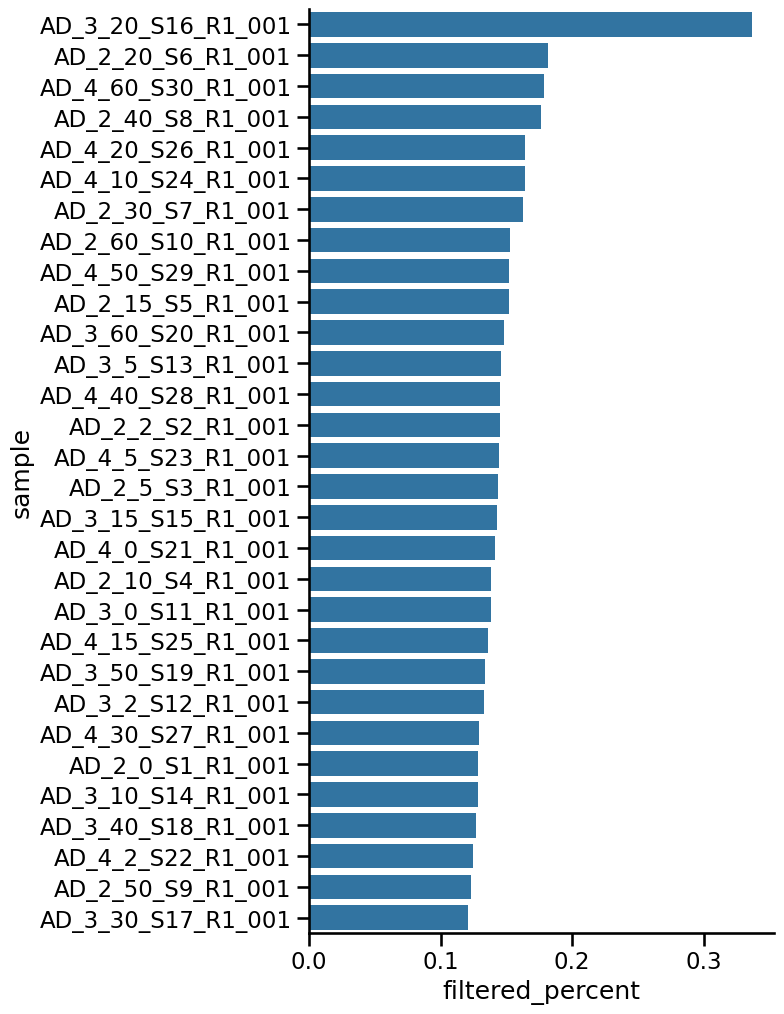

In [79]:
plt.figure(figsize = (6,12))
sns.barplot(data = AD_fastp_summary.sort_values(by = 'filtered_percent', ascending = False), y = "sample", x = "filtered_percent", color = sns.color_palette('tab10')[0])
sns.despine()

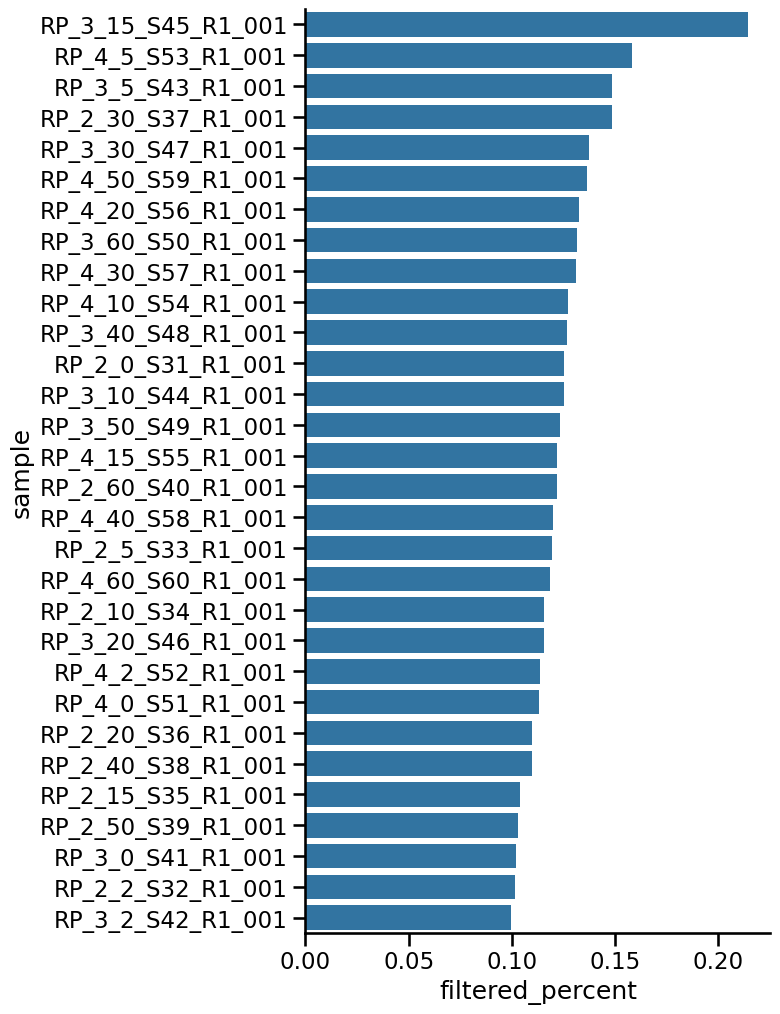

In [80]:
plt.figure(figsize = (6,12))
sns.barplot(data = RT_fastp_summary.sort_values(by = 'filtered_percent', ascending = False), y = "sample", x = "filtered_percent", color = sns.color_palette('tab10')[0])
sns.despine()

# Total reads before filtering

In [59]:
reads_merged = pd.merge(AD_fastp_summary[["total_reads", "rep", "time"]], 
         RT_fastp_summary[["total_reads", "rep", "time"]], 
         on = ["rep", "time"], suffixes = ("_AD", "_RT"))
reads_merged

,total_reads_AD,rep,time,total_reads_RT
0,15183266,4,60,50250818
1,14626601,4,50,35122937
2,14591701,2,60,57974782
3,14520038,3,20,26920997
4,14182638,2,10,15889257
5,14143977,3,40,39370359
6,13954683,2,30,33210123
7,13896953,4,2,6633730
8,13695371,3,50,48269145
9,13673257,3,10,31368150


In [60]:
sum(reads_merged["total_reads_AD"])

400925122

In [61]:
sum(reads_merged["total_reads_RT"])

773198979

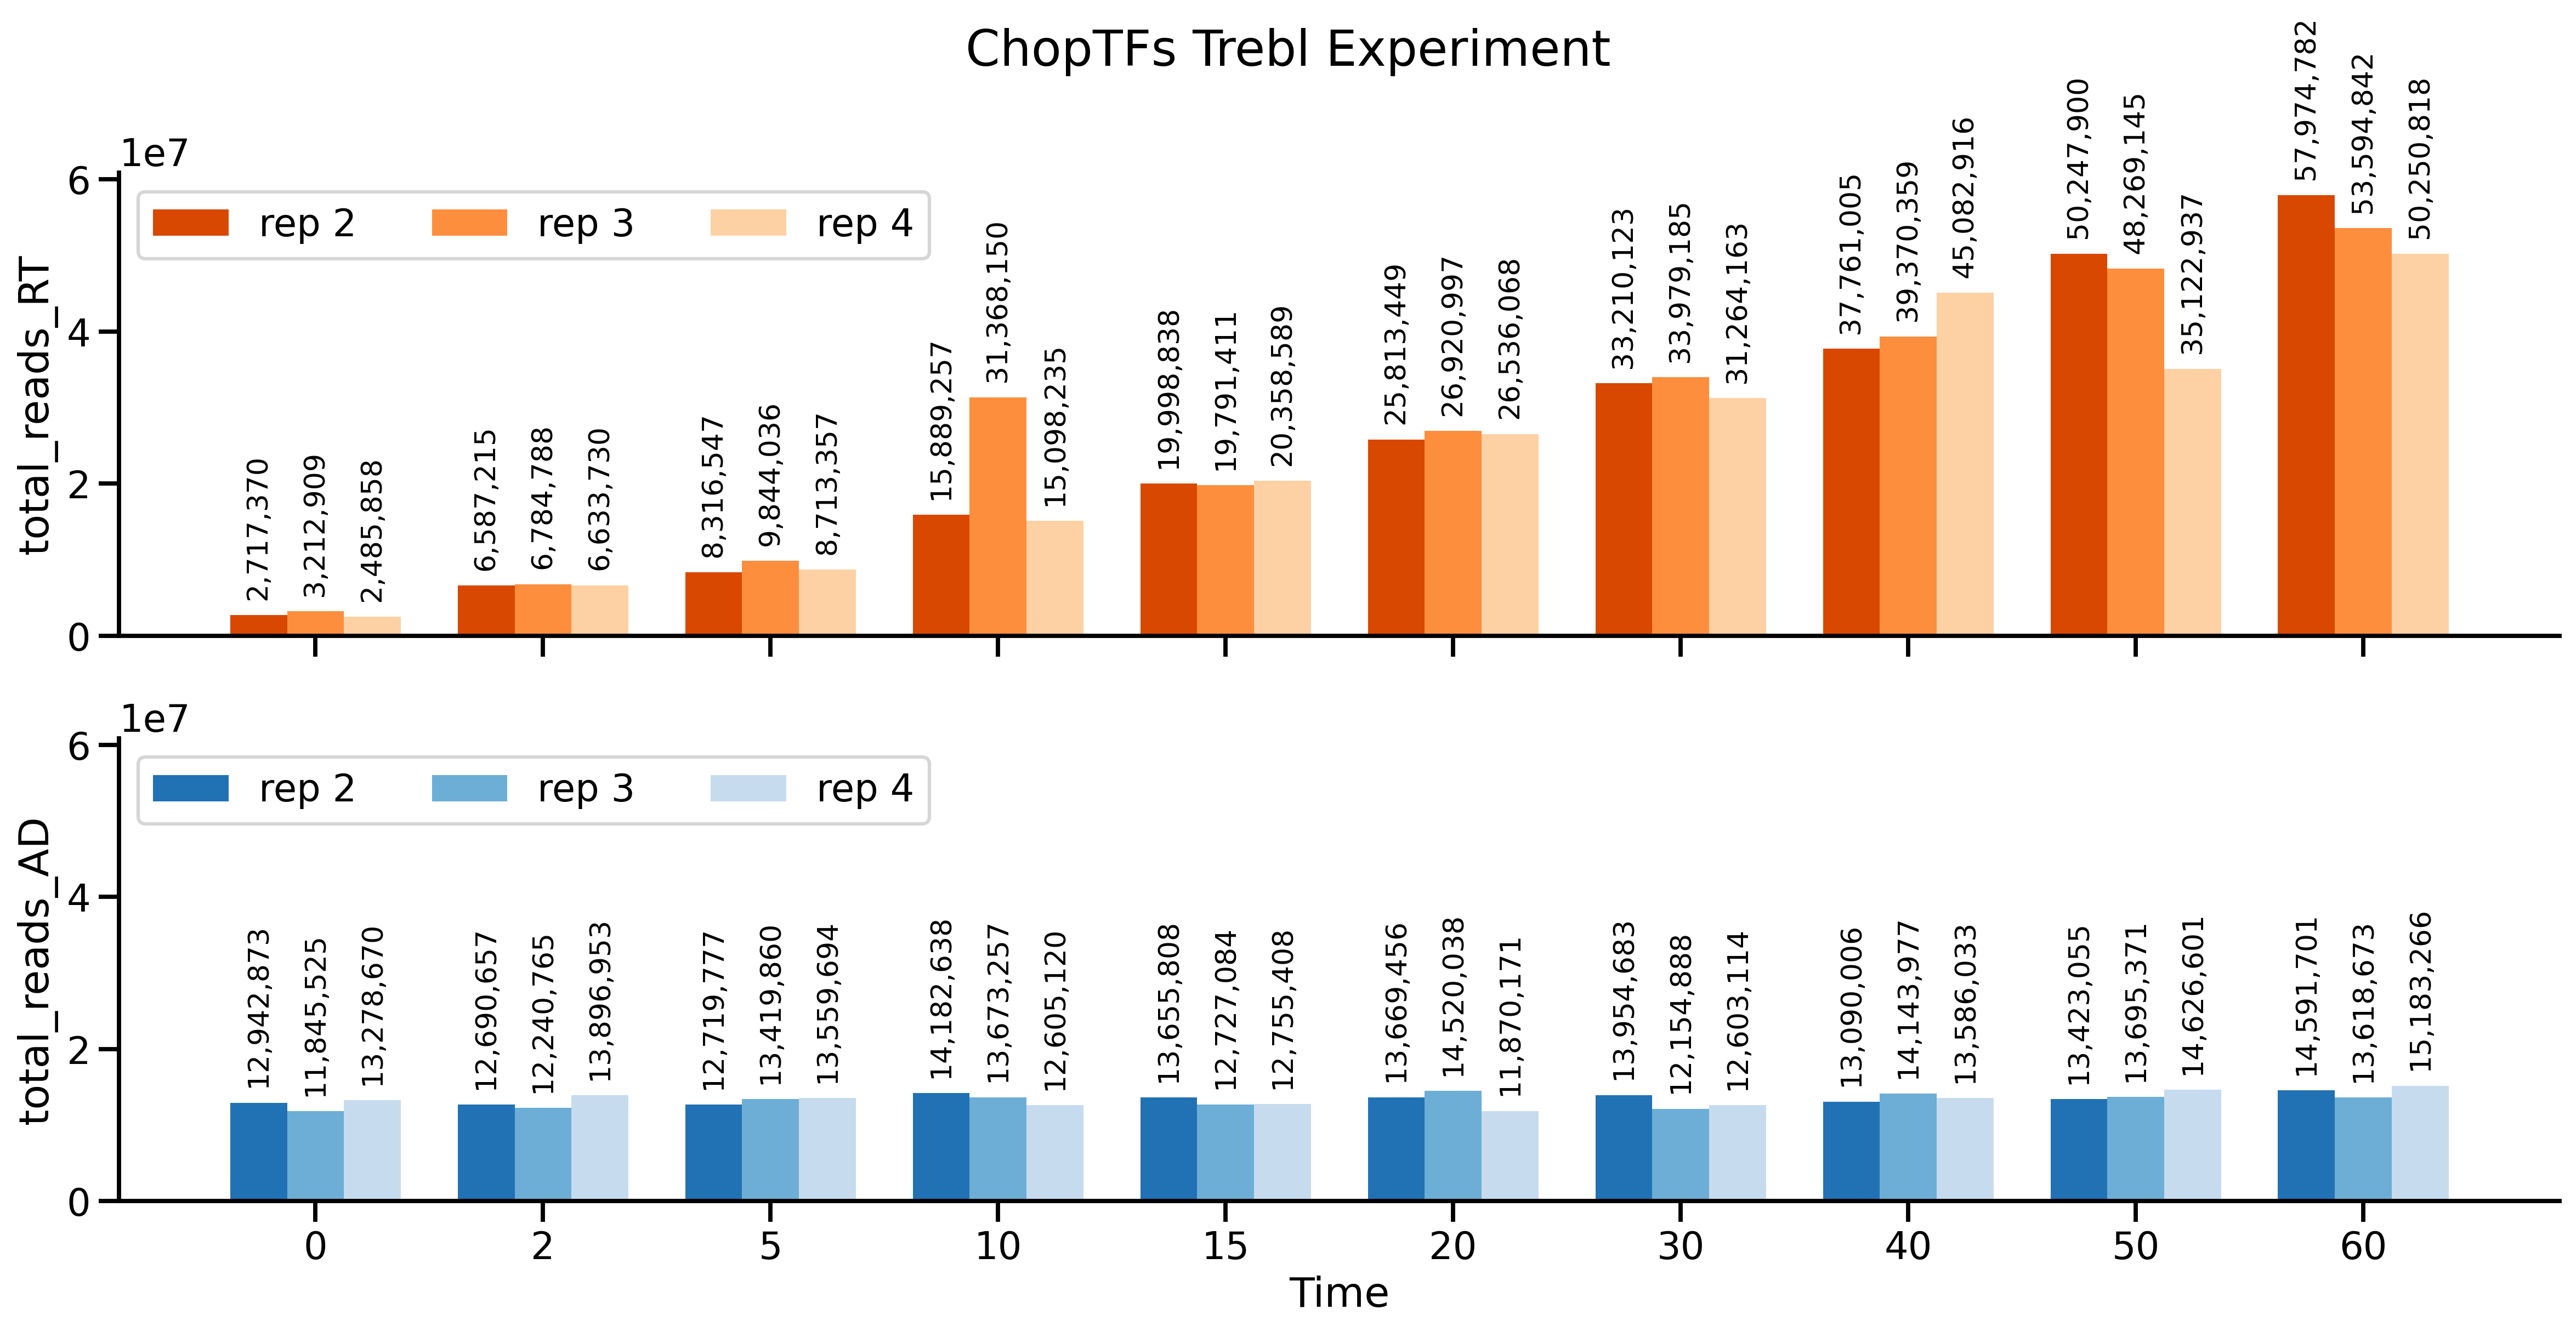

In [62]:
sns.set_context('talk')

df = reads_merged

# Sort by time
df_sorted = df.sort_values('time')

# Unique reps and times
reps = sorted(df['rep'].unique())
times = sorted(df['time'].unique())
n_reps = len(reps)
bar_width = 0.25

# Generate colors from palettes
colors_RT = sns.color_palette("Oranges_r", n_reps)
colors_AD = sns.color_palette("Blues_r", n_reps)

# Map reps to palette colors
rep_color_map_RT = {rep: colors_RT[i] for i, rep in enumerate(reps)}
rep_color_map_AD = {rep: colors_AD[i] for i, rep in enumerate(reps)}

# Create subplots
fig, axes = plt.subplots(2, 1, figsize=(16,9), sharex=True, sharey=True, dpi = 300)

# Function to plot grouped bars with numerical labels
def plot_grouped(ax, value_column, title, rep_color_map):
    for i, rep in enumerate(reps):
        # Filter for this rep
        rep_data = df_sorted[df_sorted['rep'] == rep]
        # x positions for this rep
        x = np.arange(len(times)) + i*bar_width
        # Values aligned with times
        y = [rep_data[rep_data['time']==t][value_column].values[0] if t in rep_data['time'].values else 0 for t in times]
        bars = ax.bar(x, y, width=bar_width, color=rep_color_map[rep], label=f'rep {rep}')
        
        # Add numerical labels on top of bars
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax.text(bar.get_x() + bar.get_width()/2, height + 2000000, f'{int(height):,}', 
                        ha='center', va='bottom', fontsize='x-small', rotation=90)
                
    ax.set_ylabel(value_column)
    # ax.set_title(title)
    ax.set_xticks(np.arange(len(times)) + bar_width*(n_reps-1)/2)
    ax.set_xticklabels(times)
    ax.legend(loc = 'upper left', ncols = 3)

# Plot RT reads (Oranges)
plot_grouped(axes[0], 'total_reads_RT', 'Total Reads RT by Time', rep_color_map_RT)

# Plot AD reads (Blues)
plot_grouped(axes[1], 'total_reads_AD', 'Total Reads AD by Time', rep_color_map_AD)
axes[1].set_xlabel('Time')

plt.suptitle("ChopTFs Trebl Experiment", y = 0.9)
plt.tight_layout()
sns.despine()
plt.show()